Initial Shape: (1000, 16)

Missing values:
 Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

Top Genres:
 Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Name: count, dtype: int64


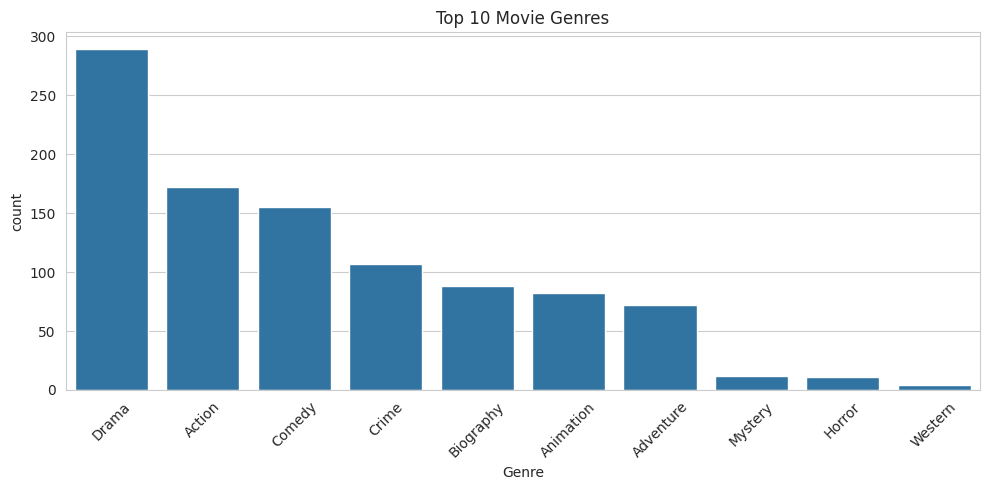

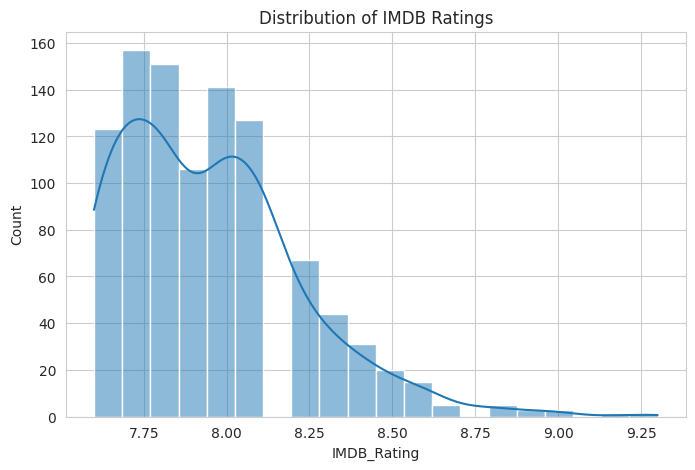

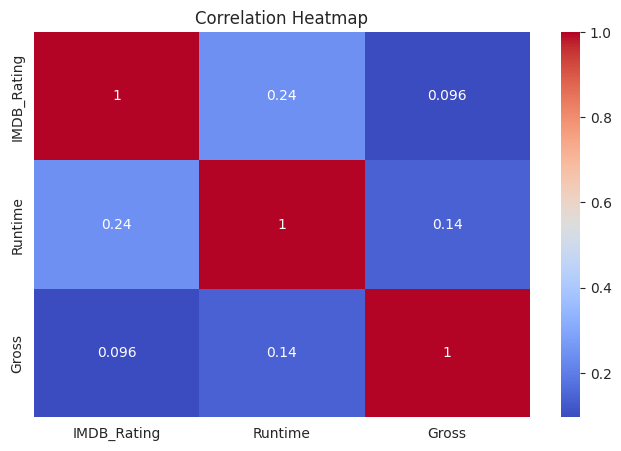


Linear Regression R² Score: 0.06

Top 5 Movies by IMDB Rating:
               Series_Title  IMDB_Rating
0  The Shawshank Redemption          9.3
1             The Godfather          9.2
4              12 Angry Men          9.0
2           The Dark Knight          9.0
3    The Godfather: Part II          9.0


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
df = pd.read_csv('imdb_top_1000.csv')

# Basic Info
print("Initial Shape:", df.shape)
df.head()

# 1. Data Cleaning
df.drop_duplicates(inplace=True)
df.dropna(subset=['Series_Title', 'IMDB_Rating'], inplace=True)
df['Genre'] = df['Genre'].str.split(',').str[0]  # First genre
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(float)
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# 2. Exploratory Data Analysis
print("\nTop Genres:\n", df['Genre'].value_counts().head())

# 3. Visualizations
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index[:10])
plt.title('Top 10 Movie Genres')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True)
plt.title('Distribution of IMDB Ratings')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['IMDB_Rating', 'Runtime', 'Gross']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Scatter Plot with Plotly
fig = px.scatter(df, x='Runtime', y='IMDB_Rating', color='Genre', hover_data=['Series_Title'])
fig.update_layout(title='IMDB Rating vs Runtime by Genre')
fig.show()

# 4. Basic ML (Optional): Predict IMDB rating using runtime & votes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df.dropna(subset=['Runtime', 'IMDB_Rating'], inplace=True)
X = df[['Runtime']]
y = df['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print(f"\nLinear Regression R² Score: {score:.2f}")

# 5. Summary Output
print("\nTop 5 Movies by IMDB Rating:")
print(df[['Series_Title', 'IMDB_Rating']].sort_values(by='IMDB_Rating', ascending=False).head())
